In [66]:
from math import log, sqrt
import os
import random
from scipy.stats import t as t_stats,norm
import numpy as np
import matplotlib.pyplot as plt
ALPHA = 0.05

In [67]:
def bernouli_sequence_generate(seed, p, n):
    random.seed(seed)
    if not (0 <= p <= 1):
        raise ValueError("Probability p must be in the range [0, 1].")
    if n <= 0:
        raise ValueError("Number of variables n must be a positive integer.")
    mean= p
    variance= p * (1 - p)
    sequence = [1 if random.random() < p else 0 for _ in range(n)]
    return mean, variance, sequence

def bernouli_sequence_empirical_mean(sequence):
    if not sequence:
        raise ValueError("The sequence must not be empty.")
    
    return sum(sequence) / len(sequence)

def bernouli_sequence__sample_variance(sequence):
    if not sequence:
        raise ValueError("The sequence must not be empty.")
    
    mean = bernouli_sequence_empirical_mean(sequence)
    variance_uncorrected = sum((x - mean) ** 2 for x in sequence) / len(sequence)
    variance_corrected = sum((x - mean) ** 2 for x in sequence) / (len(sequence) - 1) if len(sequence) > 1 else 0
    return variance_uncorrected, variance_corrected

In [68]:
def hoefding_certificate(sequence, alpha):
    if not sequence:
        raise ValueError("The sequence must not be empty.")
    if not (0 < alpha < 1):
        raise ValueError("Alpha must be in the range (0, 1).")
    t = len(sequence)
    mean = bernouli_sequence_empirical_mean(sequence)
    gamma= sqrt(log(2/alpha) / (2 * t))
    bound = (max(0, mean - gamma), min(1, mean + gamma))
    width = bound[1] - bound[0]
    return width, bound
def empirical_bernstein_certificate(sequence, alpha):
    if not sequence:
        raise ValueError("The sequence must not be empty.")
    if not (0 < alpha < 1):
        raise ValueError("Alpha must be in the range (0, 1).")
    
    t = len(sequence)
    if t < 2:
        return 1, (0, 1)
    mean = bernouli_sequence_empirical_mean(sequence)
    variance_uncorrected, variance_corrected = bernouli_sequence__sample_variance(sequence)

    gamma = sqrt((2 * variance_uncorrected * log(2/alpha)) / t) + (7 * log(2/alpha)) / (3 * (t - 1))

    bound = (mean - gamma, mean + gamma)
    bound = (max(0, bound[0]), min(1, bound[1]))
    width = bound[1] - bound[0]
    
    return width, bound
def t_test_certiicate(sequence,alpha):
    if not sequence:
        raise ValueError("The sequence must not be empty.")
    if not (0 < alpha < 1):
        raise ValueError("Alpha must be in the range (0, 1).")
    
    t = len(sequence)
    if t < 2:
        return 1, (0, 1)
    mean = bernouli_sequence_empirical_mean(sequence)
    variance_uncorrected, variance_corrected = bernouli_sequence__sample_variance(sequence)

    if variance_corrected <= 0:
        return 1, (0, 1)

    t_critical = t_stats.ppf(1 - alpha / 2, df=t - 1)
    margin_of_error = t_critical * sqrt(variance_corrected / t)
    bound = (mean - margin_of_error, mean + margin_of_error)
    bound = (max(0, bound[0]), min(1, bound[1]))
    width = bound[1] - bound[0]

    return width, bound
def sequential_t_test_certificate(sequence, alpha):
    if not sequence:
        raise ValueError("The sequence must not be empty.")
    if not (0 < alpha < 1):
        raise ValueError("Alpha must be in the range (0, 1).")
    
    t = len(sequence)
    if t < 2:
        return 1, (0, 1)
    mean = bernouli_sequence_empirical_mean(sequence)
    alpha_t= alpha / (t*(t + 1))
    variance_uncorrected, variance_corrected = bernouli_sequence__sample_variance(sequence)
    
    if variance_corrected <= 0:
        return 1, (0, 1)

    t_critical = t_stats.ppf(1 - alpha_t / 2, df=t - 1)

    margin_of_error = t_critical * sqrt(variance_corrected / t)
    bound = (max(0, mean - margin_of_error), min(1, mean + margin_of_error))
    width = bound[1] - bound[0]

    return width, bound
def z_test_certificate(sequence, alpha):
    if not sequence:
        raise ValueError("The sequence must not be empty.")
    if not (0 < alpha < 1):
        raise ValueError("Alpha must be in the range (0, 1).")
    
    t = len(sequence)
    mean = bernouli_sequence_empirical_mean(sequence)
    std_deviation=0.5

    z_critical = norm.ppf(1 - alpha / 2)
    margin_of_error = z_critical * (std_deviation / sqrt(t))
    bound = (max(0, mean - margin_of_error), min(1, mean + margin_of_error))
    width = bound[1] - bound[0]
    
    return width, bound

DEFAULT_GRID = np.round(np.arange(0.02, 1.0, 0.02), 2)
def truncate_stake(stake, candidate_mean, delta=0.05):
    candidate_mean = np.asarray(candidate_mean, dtype=float)
    lower = -(1.0 - delta) / np.maximum(1.0 - candidate_mean, 1e-12)
    upper = (1.0 - delta) / np.maximum(candidate_mean, 1e-12)
    return np.clip(stake, lower, upper)
def running_moments(samples, initial_mean=0.5, initial_variance=0.25, variance_floor=1e-4):
    samples = np.asarray(samples, dtype=float).ravel()
    means = np.empty(samples.size, dtype=float)
    variances = np.empty(samples.size, dtype=float)
    sum_x = 0.0
    sum_x2 = 0.0

    for t, x in enumerate(samples):
        if t == 0:
            means[t] = initial_mean
            variances[t] = initial_variance
        else:
            mean = sum_x / t
            means[t] = mean
            variances[t] = max(sum_x2 / t - mean**2, variance_floor)
        sum_x += x
        sum_x2 += x**2

    return means, variances
def wealth_grid(samples, grid=DEFAULT_GRID, means=None, variances=None, kappa=0.5):
    samples = np.asarray(samples, dtype=float).ravel()
    grid = np.asarray(grid, dtype=float).ravel()

    if means is None or variances is None:
        means, variances = running_moments(samples)
    means = np.asarray(means, dtype=float).ravel()
    variances = np.asarray(variances, dtype=float).ravel()

    if means.size != samples.size or variances.size != samples.size:
        raise ValueError("means and variances must have the same length as samples")

    candidates = grid[:, None]
    edge = means[None, :] - candidates
    raw_stakes = kappa * edge / (variances[None, :] + edge**2)
    stakes = truncate_stake(raw_stakes, candidates)
    factors = np.maximum(1.0 + stakes * (samples[None, :] - candidates), 1e-12)
    wealths = np.cumprod(factors, axis=1)
    return wealths

def confidence_sequence_from_wealth(grid, wealth, alpha=0.05):
    grid = np.asarray(grid, dtype=float).ravel()
    wealth = np.asarray(wealth, dtype=float)
    threshold = 1.0 / alpha

    if wealth.shape[0] != grid.size:
        raise ValueError("wealth must have one row per grid point")

    lower = np.zeros(wealth.shape[1], dtype=float)
    upper = np.ones(wealth.shape[1], dtype=float)

    for t in range(wealth.shape[1]):
        accepted = np.flatnonzero(wealth[:, t] < threshold)
        if accepted.size == 0:
            continue
        if accepted[0] > 0:
            lower[t] = grid[accepted[0] - 1]
        if accepted[-1] < grid.size - 1:
            upper[t] = grid[accepted[-1] + 1]

    return lower, upper

def refined_confidence_sequence_from_wealth(
    grid,
    wealth,
    wealth_fn,
    alpha=0.05,
    tol=1e-3,
    max_iter=12,
):
    grid = np.asarray(grid, dtype=float).ravel()
    wealth = np.asarray(wealth, dtype=float)
    threshold = 1.0 / alpha
    lower, upper = confidence_sequence_from_wealth(grid, wealth, alpha)

    accepted_by_time = [
        np.flatnonzero(wealth[:, time_index] < threshold)
        for time_index in range(wealth.shape[1])
    ]

    lower_times = []
    lower_a = []
    lower_b = []
    upper_times = []
    upper_a = []
    upper_b = []

    for time_index, accepted in enumerate(accepted_by_time):
        if accepted.size == 0:
            continue

        first = accepted[0]
        if first > 0:
            lower_times.append(time_index)
            lower_a.append(grid[first - 1])
            lower_b.append(grid[first])

        last = accepted[-1]
        if last < grid.size - 1:
            upper_times.append(time_index)
            upper_a.append(grid[last])
            upper_b.append(grid[last + 1])

    def refine_side(times, a_values, b_values, side):
        if not times:
            return None

        times = np.asarray(times, dtype=int)
        a_values = np.asarray(a_values, dtype=float)
        b_values = np.asarray(b_values, dtype=float)

        for _ in range(max_iter):
            mids = 0.5 * (a_values + b_values)
            mid_wealth = wealth_fn(mids)[np.arange(mids.size), times]
            rejected = mid_wealth >= threshold

            if side == "lower":
                a_values = np.where(rejected, mids, a_values)
                b_values = np.where(rejected, b_values, mids)
            else:
                a_values = np.where(rejected, a_values, mids)
                b_values = np.where(rejected, mids, b_values)

            if np.all(b_values - a_values <= tol):
                break

        values = a_values if side == "lower" else b_values
        return times, values

    refined_lower = refine_side(lower_times, lower_a, lower_b, "lower")
    if refined_lower is not None:
        times, values = refined_lower
        lower[times] = values

    refined_upper = refine_side(upper_times, upper_a, upper_b, "upper")
    if refined_upper is not None:
        times, values = refined_upper
        upper[times] = values

    return lower, upper
def wsr_certificate(sequence, alpha,kappa=0.5,hypothesis_mean=0,tol=1e-3,grid=DEFAULT_GRID):
    if not sequence:
        raise ValueError("The sequence must not be empty.")
    if not (0 < alpha < 1):
        raise ValueError("Alpha must be in the range (0, 1).")
    
    means,variances=running_moments(sequence)
    wealths = wealth_grid(sequence, grid=grid, means=means, variances=variances, kappa=kappa)
    wealth_fn = lambda candidates: wealth_grid(sequence, candidates, means, variances, kappa)
    lower, upper = refined_confidence_sequence_from_wealth(grid, wealths, wealth_fn, alpha=alpha, tol=tol)
    bound = (max(0, lower[-1]), min(1, upper[-1]))
    width = bound[1] - bound[0]
    return width, bound

def hypothesis_wealth_path(sequence, hypothesis_mean, kappa=0.5):
    if not sequence:
        raise ValueError("The sequence must not be empty.")

    means, variances = running_moments(sequence)
    wealths = wealth_grid(sequence, np.array([hypothesis_mean], dtype=float),
                          means, variances, kappa)
    return wealths[0]


def hypothesis_rejection_time(sequence, hypothesis_mean, alpha, kappa=0.5):
    path = hypothesis_wealth_path(sequence, hypothesis_mean, kappa=kappa)
    reached = np.flatnonzero(path >= 1.0 / alpha)
    return int(reached[0]) + 1 if reached.size else None


def hypothesis_wealth(sequence, hypothesis_mean, kappa=0.5):
    return float(hypothesis_wealth_path(sequence, hypothesis_mean, kappa=kappa)[-1])



def certificate_path(certificate_fn, sequence, alpha=ALPHA):
    n = len(sequence)
    widths = np.empty(n, dtype=float)
    bounds = np.empty((n, 2), dtype=float)
    for t in range(1, n + 1):
        width, bound = certificate_fn(sequence[:t], alpha)
        widths[t - 1] = float(width)
        bounds[t - 1] = (float(bound[0]), float(bound[1]))
    return widths, bounds


def wsr_certificate_path(sequence, alpha=ALPHA, kappa=0.5, tol=1e-3, grid=DEFAULT_GRID):
    if not sequence:
        raise ValueError("The sequence must not be empty.")
    if not (0 < alpha < 1):
        raise ValueError("Alpha must be in the range (0, 1).")

    means, variances = running_moments(sequence)
    wealths = wealth_grid(sequence, grid=grid, means=means, variances=variances, kappa=kappa)
    wealth_fn = lambda candidates: wealth_grid(sequence, candidates, means, variances, kappa)
    lower, upper = refined_confidence_sequence_from_wealth(
        grid, wealths, wealth_fn, alpha=alpha, tol=tol
    )
    bounds = np.column_stack((np.maximum(lower, 0.0), np.minimum(upper, 1.0)))
    return bounds[:, 1] - bounds[:, 0], bounds


def all_certificate_paths(sequence, alpha=ALPHA, kappas=(0.5,)):
    paths = {
        "Hoeffding": certificate_path(hoefding_certificate, sequence, alpha),
        "empirical Bernstein": certificate_path(empirical_bernstein_certificate, sequence, alpha),
        "t-test": certificate_path(t_test_certiicate, sequence, alpha),
        "z-test": certificate_path(z_test_certificate, sequence, alpha),
        "sequential t-test": certificate_path(sequential_t_test_certificate, sequence, alpha),
    }
    for kappa in kappas:
        paths[f"WSR ($\kappa$={kappa})"] = wsr_certificate_path(sequence, alpha, kappa=kappa)
    return paths


<>:309: SyntaxWarning: invalid escape sequence '\k'
<>:309: SyntaxWarning: invalid escape sequence '\k'
/tmp/ipykernel_2557673/2767273709.py:309: SyntaxWarning: invalid escape sequence '\k'
  paths[f"WSR ($\kappa$={kappa})"] = wsr_certificate_path(sequence, alpha, kappa=kappa)


In [ ]:
PATH_STYLES = {
    "Hoeffding":           {"color": "#31a354", "linestyle": "--", "linewidth": 1.8},
    "empirical Bernstein": {"color": "#006d2c", "linestyle": "-.", "linewidth": 1.8},
    "t-test":              {"color": "#969696", "linestyle": ":",  "linewidth": 1.9},
    "z-test":              {"color": "#636363", "linestyle": "-.", "linewidth": 1.9},
    "sequential t-test":   {"color": "#252525", "linestyle": "--", "linewidth": 1.9},
}
WSR_STYLES = [
    {"color": "#d95f02", "linestyle": "-", "linewidth": 2.1},
    {"color": "#e08214", "linestyle": "-", "linewidth": 1.8, "alpha": 0.85},
    {"color": "#fdb863", "linestyle": "-", "linewidth": 1.6, "alpha": 0.85},
]



FIG_SIZE = (6.0, 3.2)
LEGEND_INCHES = 0.44

Y_MIN = 0.4

INVALID_LABEL = "Invalid certificate"
INVALID_LABEL_XY = (0.75, 0.1)
INVALID_COLOR = "#c1272d"
def annotate_invalid(ax, paths, points, label_xy=INVALID_LABEL_XY):
    for index, (name, n) in enumerate(points):
        _, bounds = paths[name]
        ax.annotate(
            INVALID_LABEL if index == 0 else "",
            xy=(n, bounds[n - 1, 1]),
            xytext=label_xy, textcoords="axes fraction",
            ha="center", va="top",
            fontsize=12, color=INVALID_COLOR,
            arrowprops={
                "arrowstyle": "->",
                "color": INVALID_COLOR,
                "linewidth": 1.3,
                "shrinkA": 5,
                "shrinkB": 4,
                "connectionstyle": "arc3,rad=0",
            },
        )


def plot_certificate_paths(paths, true_mean, save, alpha=ALPHA):

    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman"],
        "mathtext.fontset": "stix",
        "font.size": 12,
        "axes.titlesize": 12,
        "axes.labelsize": 12,
        "legend.fontsize": 12,
    })

    fig, ax_bound = plt.subplots(1, 1, figsize=FIG_SIZE)
    handles = {}
    wsr_index = 0
    n_total = 0

    for name, (widths, bounds) in paths.items():
        if name in PATH_STYLES:
            style = PATH_STYLES[name]
        else:
            style = WSR_STYLES[wsr_index % len(WSR_STYLES)]
            wsr_index += 1
        n_axis = np.arange(1, widths.size + 1)
        n_total = max(n_total, widths.size)

        line, = ax_bound.plot(n_axis, bounds[:, 0], marker="o", markersize=3.5, **style)
        ax_bound.plot(n_axis, bounds[:, 1], marker="o", markersize=3.5, **style)
        handles[name] = line

    ticks = np.arange(1, n_total + 1) if n_total <= 20 else None

    ax_bound.axhline(true_mean, color="#c1272d", linewidth=1.4, linestyle=(0, (4, 3)), zorder=0)
    ax_bound.annotate(f"True mean $\mu^*={true_mean:g}$", xy=(0.8, true_mean),
                      xytext=(0, -5), textcoords="offset points",
                      color="#c1272d", fontsize=12, va="top")
    ax_bound.set_xlabel("Samples $t$", labelpad=-10)
    ax_bound.tick_params(axis="x", pad=1.5)
    ax_bound.set_ylabel("Upper bound $r_u$")
    # ax_bound.set_title("Sequence certificates")

    ax_bound.set_ylim(Y_MIN, 1.03)
    if ticks is not None:
        ax_bound.set_xticks(ticks)
        ax_bound.set_xticklabels(
            [str(t) if t in (ticks[0], ticks[-1]) else "" for t in ticks]
        )
    ax_bound.grid(alpha=0.25)

    annotate_invalid(ax_bound, paths, [("z-test", 5), ("t-test", 7)])

    fig.legend(
        list(handles.values()), list(handles.keys()),
        loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 0.08),
        borderpad=0.0, borderaxespad=0.0, labelspacing=0.2,
        columnspacing=0.5, handletextpad=0.35, handlelength=1.4,
    )
    fig.tight_layout(rect=(0, LEGEND_INCHES / FIG_SIZE[1], 1, 1))
    fig.savefig(save, dpi=180)
    print(f"saved {save}")


<>:77: SyntaxWarning: invalid escape sequence '\m'
<>:77: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2557673/425757004.py:77: SyntaxWarning: invalid escape sequence '\m'
  ax_bound.annotate(f"True mean $\mu^*={true_mean:g}$", xy=(0.8, true_mean),


seed = 178, u = 0.55, n = 8, alpha = 0.05, kappa = (0.6, 0.95)
ground truth mean: 0.55, variance: 0.2475, empirical mean: 0.125
Bernoulli Sequence: [0, 0, 0, 0, 0, 1, 0, 0]
saved /home/yjchen/project/Bet4Sim2Real-Certificate/synthetic/example_certificate_paths.png


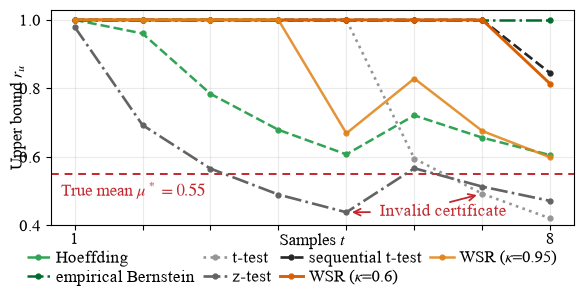

In [70]:
if __name__ == "__main__":
    seed = 178
    p = 0.55
    u = 0.55
    n = 8
    kappa_low = 0.60
    kappa_high = 0.95
    ground_truth_mean,ground_truth_variance, bernouli_sequence = bernouli_sequence_generate(seed, p, n)
    print(f"seed = {seed}, u = {u}, n = {n}, alpha = {ALPHA}, kappa = ({kappa_low}, {kappa_high})")
    print(f"ground truth mean: {ground_truth_mean}, variance: {ground_truth_variance}, "
          f"empirical mean: {bernouli_sequence_empirical_mean(bernouli_sequence)}")
    print(f"Bernoulli Sequence: {[int(x) for x in bernouli_sequence]}")

    paths = all_certificate_paths(bernouli_sequence, ALPHA, kappas=(kappa_low, kappa_high))
    plot_certificate_paths(
        paths,
        true_mean=u,
        save=os.path.join(os.getcwd(), "example_certificate_paths.png"),

        alpha=ALPHA,
    )